In [1]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest
from pydose_rt.physics.fluence.fluence_modeling import compute_profile_ratios, create_radial_correction_map

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

measurements = loaders.load_asc_measurements("/home/bolo/Documents/PyDoseRT/test_data/10 MV Photons/TrueBeam X10 Squares OK.asc", coord_map=("X", "Z", "Y"))
field_size = 400

measurements = [measurement for measurement in measurements if measurement["header_dict"]["FSZ"] == [str(field_size), str(field_size)]]
measurements = [measurement for measurement in measurements if measurement["header_dict"]["EDS"][2] == measurement["header_dict"]["STS"][2]]
measurements = [measurement for measurement in measurements if (float(measurement["header_dict"]["STS"][2]) == 100.0) and (float(measurement["header_dict"]["EDS"][2]) == 100.0)]

In [2]:
resolution = (1.0, 1.0, 1.0)
ct_array_shape = (500, 500, 500)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
number_of_beams=1
starting_angle=0
iso_center=(0.0, -149.5, 0.0)
kernel_size=1001
beam = Beam.create(
    gantry_angle_deg=0.0, 
    number_of_leaf_pairs=60, 
    collimator_angle_deg=0.0, 
    field_size_mm=(field_size, field_size),
    iso_center=iso_center, 
    device=device, 
    dtype=dtype)

In [3]:

machine_config = MachineConfig(
    preset="../src/pydose_rt/data/machine_presets/umea_10MV.json",
    profile_corrections=None
    )
dose_engine = DoseEngine(
    machine_config, 
    kernel_size,
    phantom._resolution,
    image_template=phantom.density_image,
    beam_template=beam,
    device=device,
    dtype=dtype,
    adjust_values=False
)

dose = dose_engine.compute_dose(
    beam,
    ct_image=phantom.density_image).detach()
dose = dose


In [4]:
data = []

for i, measurement in enumerate(measurements):
    samples = sample_tensor_nearest(dose[0, ...], resolution, iso_center, measurement["coords_engine"])
    samples = samples * measurement["dose"].max() / samples.max()
    mape = np.mean(np.abs(samples - measurement["dose"])[measurement["dose"] > 0] /  measurement["dose"][measurement["dose"] > 0])
    thr_20 = 0.2 * measurement["dose"].max()
    thr_80 = 0.8 * measurement["dose"].max()
    penumbra_pred = sum((samples > thr_20) * (samples < thr_80))
    penumbra_measurement = sum((measurement["dose"] > thr_20) * (measurement["dose"] < thr_80))

    coords = measurement["coords_engine"]  # shape (N, 3) presumably

    # Indices of coordinates that actually change
    var_mask = np.var(coords, axis=0) != 0
    changing_idx = np.where(var_mask)[0]

    if changing_idx.size == 0:
        raise ValueError("No changing coordinates found in coords_engine.")

    # Compute physical distance along the line (only over changing components)
    # This works for 1D, 2D (diagonal), or 3D profiles
    diffs = np.diff(coords[:, changing_idx], axis=0)              # (N-1, k)
    seg_len = np.linalg.norm(diffs, axis=1)                       # (N-1,)
    dist = np.concatenate(([0.0], np.cumsum(seg_len)))            # (N,)
    ticks = dist - np.mean(dist)                                  # center at 0
    num_points = len(ticks)//2
    data.append((ticks[num_points::2], samples[num_points::2], measurement["dose"][num_points::2]))



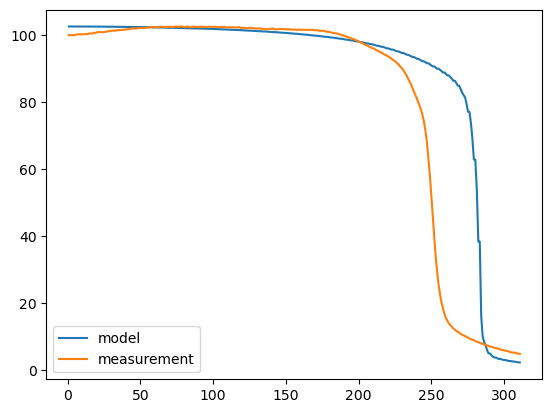

In [5]:
plt.plot(data[0][0], data[0][1], label="model")
plt.plot(data[0][0], data[0][2], label="measurement")
plt.legend()

In [6]:

# Stage 1: Compute sampled ratios
num_sampling_points = data[0][0].shape[0]
sample_points = np.linspace(0, 300, 61, endpoint=True)  # [0, 10, 20, ..., 500]
distances, ratios = compute_profile_ratios(
    data[0][2], data[0][1], data[0][0], sample_points
)

print(f"Sampled {len(ratios)} points")
print(f"Sample distances: {distances[:5]}... {distances[-5:]}")
print(f"Sample ratios: {ratios[:5]}... {ratios[-5:]}")


Sampled 61 points
Sample distances: [ 0.  5. 10. 15. 20.]... [280. 285. 290. 295. 300.]
Sample ratios: [0.97442945 0.97498654 0.97768854 0.97975094 0.98278294]... [0.13918943 0.69130399 1.43451703 1.79446626 1.94780649]


In [7]:
# Stage 2: Create correction map
image_shape = (num_sampling_points*2, num_sampling_points*2)  # height, width
pixel_size = 1.0  # 1 mm per pixel
    
correction_map = create_radial_correction_map(
    distances,
    ratios,
    image_shape,
    pixel_size,
).cpu().detach().numpy()

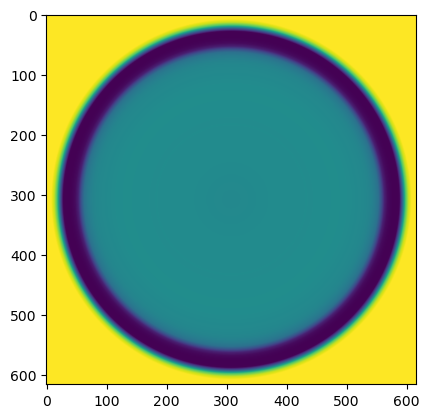

In [8]:
plt.imshow(correction_map)

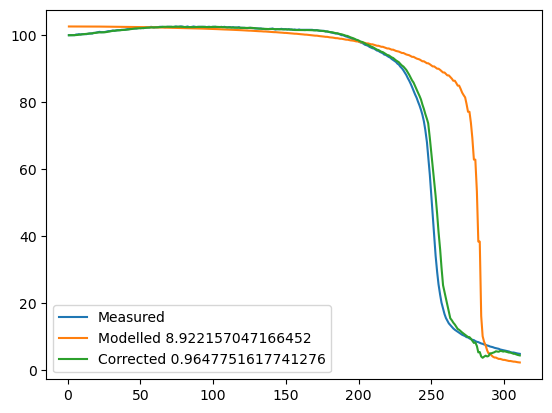

In [9]:
plt.plot(data[0][0], data[0][2], label="Measured")
plt.plot(data[0][0], data[0][1], label=f"Modelled {np.mean(np.abs(data[0][2] - data[0][1]))}")
plt.plot(data[0][0], correction_map[num_sampling_points:, num_sampling_points] * data[0][1], label=f"Corrected {np.mean(np.abs(data[0][2] - correction_map[num_sampling_points:, num_sampling_points] * data[0][1]))}")
plt.legend(loc="lower left")

In [10]:

profiles = np.round(np.stack([distances, ratios], 0), 4)

def fmt(x):
    s = np.format_float_positional(x, trim='-')
    return s if '.' in s else s + '.0'

formatted = np.array2string(
    profiles,
    formatter={'float_kind': fmt},
    separator=', '       # ← comma between values
)

print(formatted)

[[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0,
  60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 100.0, 105.0, 110.0,
  115.0, 120.0, 125.0, 130.0, 135.0, 140.0, 145.0, 150.0, 155.0, 160.0,
  165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0, 200.0, 205.0, 210.0,
  215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0,
  265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0, 300.0],
 [0.9744, 0.975, 0.9777, 0.9798, 0.9828, 0.9838, 0.9879, 0.9901, 0.992,
  0.9955, 0.9969, 0.9992, 1.0, 1.002, 1.0023, 1.0034, 1.0029, 1.0035,
  1.0049, 1.005, 1.0065, 1.0065, 1.0064, 1.007, 1.0072, 1.0085, 1.0075,
  1.0078, 1.0091, 1.0097, 1.0111, 1.0111, 1.013, 1.0148, 1.0163, 1.0164,
  1.0157, 1.014, 1.0113, 1.0062, 1.0008, 0.9943, 0.988, 0.9824, 0.9759,
  0.9666, 0.951, 0.918, 0.8736, 0.8043, 0.5755, 0.2847, 0.1763, 0.1441,
  0.1289, 0.1256, 0.1392, 0.6913, 1.4345, 1.7945, 1.9478]]
